In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
def cds_pv(notional_m, spread_bps, maturity, recovery_rate, discount_rate, hazard_rate):
    """
    Price a Credit Default Swap using a reduced-form hazard rate model.

    Parameters:
    
    notional_m    : float  – Notional in millions (e.g. 10 for $10m)
    spread_bps    : float  – CDS spread in basis points (e.g. 150 for 1.50%)
    maturity      : int    – Contract maturity in years
    recovery_rate : float  – Recovery rate as decimal (e.g. 0.4 for 40%)
    discount_rate : float  – Risk-free discount rate as decimal (e.g. 0.03 for 3%)
    hazard_rate   : float  – Implied hazard rate as decimal (e.g. 0.025)

    Returns:
    
    premium_leg   : float  – PV of all spread payments made by protection buyer
    protection_leg: float  – PV of contingent default payment made by protection seller
    npv           : float  – Net present value (protection leg minus premium leg)
                             Positive means the contract favours the protection buyer.
    """

    notional      = notional_m * 1_000_000          # Convert millions to dollars
    spread        = spread_bps / 10_000             # Convert bps to decimal
    payment_times = np.arange(1, maturity + 1)      # Annual payment dates: [1, 2, ..., T]

    # Discount factor at each payment date: e^(-r * t)
    discount_factors = np.exp(-discount_rate * payment_times)

    # Survival probability at each payment date: e^(-lambda * t)
    # S(t) is the probability the reference entity has not defaulted by time t
    survival_probs = np.exp(-hazard_rate * payment_times)

    # Survival probability at the start of each period
    # S(0) = 1 by definition; then S(1), S(2), ..., S(T-1)
    prev_survival_probs = np.insert(survival_probs[:-1], 0, 1.0)

    # Premium leg: spread payment at each date, weighted by discount factor and
    # survival probability (payment only occurs if no prior default)
    premium_leg = notional * spread * np.sum(discount_factors * survival_probs)

    # Protection leg: LGD payment weighted by the probability of defaulting in
    # each period. Period default probability = S(t-1) - S(t)
    lgd = 1 - recovery_rate
    default_probs = prev_survival_probs - survival_probs
    protection_leg = notional * lgd * np.sum(discount_factors * default_probs)

    npv = protection_leg - premium_leg

    return premium_leg, protection_leg, npv

In [7]:
# Sanity Check: verifying the pricing function
# Base case: known inputs with a roughly fair spread 
premium, protection, npv = cds_pv(
    notional_m    = 10,     # $10 million
    spread_bps    = 100,    # 100 bps (1.00%)
    maturity      = 5,
    recovery_rate = 0.4,    # 40% recovery
    discount_rate = 0.03,   # 3% risk-free rate
    hazard_rate   = 0.0167  # approx 100bps / (1 - 0.4)
)

print("Base Case:")
print(f"Premium Leg PV:    ${premium:>12,.2f}")
print(f"Protection Leg PV: ${protection:>12,.2f}")
print(f"NPV:               ${npv:>12,.2f}")
print()

# Sensitivity check: NPV should rise as hazard rate increases
print("Hazard Rate Sensitivity:")
print(f"{'Hazard Rate':>15} {'NPV':>15}")
for hr in [0.01, 0.02, 0.03, 0.05, 0.10]:
    _, _, npv_check = cds_pv(10, 100, 5, 0.4, 0.03, hr)
    print(f"{hr*100:>14.1f}%  ${npv_check:>12,.2f}")

Base Case:
Premium Leg PV:    $  435,584.13
Protection Leg PV: $  440,120.07
NPV:               $    4,535.94

Hazard Rate Sensitivity:
    Hazard Rate             NPV
           1.0%  $ -176,331.07
           2.0%  $   91,497.98
           3.0%  $  346,742.91
           5.0%  $  821,860.14
          10.0%  $1,828,198.80


In [10]:
# Widget definitions
style  = {'description_width': '250px'}
layout = widgets.Layout(width='700px')

notional_w  = widgets.FloatText(value=10,  description='Notional ($ millions):', style=style, layout=layout)
spread_w    = widgets.FloatText(value=150, description='Spread (bps):',          style=style, layout=layout)
maturity_w  = widgets.IntText( value=5,   description='Maturity (years):',       style=style, layout=layout)
recovery_w  = widgets.FloatText(value=40, description='Recovery Rate (%):',      style=style, layout=layout)
discount_w  = widgets.FloatText(value=3,  description='Discount Rate (%):',      style=style, layout=layout)
update_btn  = widgets.Button(description='Update')
output      = widgets.Output()


def update_pricer(_):
    """Reprice the CDS across a hazard rate sweep and update the chart."""

    # Read and convert widget inputs
    notional_m    = notional_w.value
    spread_bps    = spread_w.value
    maturity      = maturity_w.value
    recovery_rate = recovery_w.value / 100
    discount_rate = discount_w.value / 100

    # Sweep hazard rates from 0.1% to 20%
    hazard_rates = np.linspace(0.001, 0.20, 500)
    premiums, protections, npvs = [], [], []

    for hr in hazard_rates:
        p, prot, npv = cds_pv(notional_m, spread_bps, maturity, recovery_rate, discount_rate, hr)
        premiums.append(p)
        protections.append(prot)
        npvs.append(npv)

    npvs_arr = np.array(npvs)

    # Find breakeven hazard rate by linear interpolation across sign change
    breakeven = None
    sign_changes = np.where(np.diff(np.sign(npvs_arr)))[0]
    if len(sign_changes) > 0:
        i  = sign_changes[0]
        x0, x1 = hazard_rates[i] * 100, hazard_rates[i + 1] * 100
        y0, y1 = npvs_arr[i], npvs_arr[i + 1]
        breakeven = x0 - y0 * (x1 - x0) / (y1 - y0)

    hr_pct = hazard_rates * 100

    with output:
        clear_output(wait=True)

        fig = go.Figure()

       # Shaded positive NPV region
        fig.add_trace(go.Scatter(
            x=hr_pct,
            y=np.where(npvs_arr > 0, npvs_arr, 0),
            fill='tozeroy',
            mode='none',
            fillcolor='rgba(0, 180, 0, 0.1)',
            name='Positive NPV',
            hoverinfo='skip'
        ))
        
        # Shaded negative NPV region
        fig.add_trace(go.Scatter(
            x=hr_pct,
            y=np.where(npvs_arr < 0, npvs_arr, 0),
            fill='tozeroy',
            mode='none',
            fillcolor='rgba(200, 0, 0, 0.1)',
            name='Negative NPV',
            hoverinfo='skip'
        ))

        # Premium leg
        fig.add_trace(go.Scatter(
            x=hr_pct, y=premiums,
            mode='lines', name='Premium Leg PV',
            hovertemplate='Hazard Rate: %{x:.2f}%<br>Premium Leg: $%{y:,.0f}<extra></extra>'
        ))

        # Protection leg
        fig.add_trace(go.Scatter(
            x=hr_pct, y=protections,
            mode='lines', name='Protection Leg PV',
            hovertemplate='Hazard Rate: %{x:.2f}%<br>Protection Leg: $%{y:,.0f}<extra></extra>'
        ))

        # NPV line
        fig.add_trace(go.Scatter(
            x=hr_pct, y=npvs,
            mode='lines', name='NPV',
            hovertemplate='Hazard Rate: %{x:.2f}%<br>NPV: $%{y:,.0f}<extra></extra>'
        ))

        # Breakeven annotation
        if breakeven is not None:
            fig.add_trace(go.Scatter(
                x=[breakeven], y=[0],
                mode='markers+text',
                marker=dict(color='black', size=9),
                text=[f'Breakeven: {breakeven:.2f}%'],
                textposition='top right',
                name='Breakeven',
                hovertemplate='Breakeven Hazard Rate: %{x:.2f}%<extra></extra>'
            ))

        fig.update_layout(
            title='CDS Valuation vs Hazard Rate',
            xaxis=dict(
                title='Hazard Rate (%)',
                showgrid=True, gridcolor='LightGray',
                showline=True, linecolor='Black',
                dtick=2
            ),
            yaxis=dict(
                title='Value ($)',
                showgrid=True, gridcolor='LightGray',
                showline=True, linecolor='Black'
            ),
            hovermode='x unified',
            height=600,
            legend=dict(x=0.01, y=0.99)
        )

        fig.show()


update_btn.on_click(update_pricer)

display(notional_w, spread_w, maturity_w, recovery_w, discount_w, update_btn, output)
update_pricer(None)

FloatText(value=10.0, description='Notional ($ millions):', layout=Layout(width='700px'), style=DescriptionSty…

FloatText(value=150.0, description='Spread (bps):', layout=Layout(width='700px'), style=DescriptionStyle(descr…

IntText(value=5, description='Maturity (years):', layout=Layout(width='700px'), style=DescriptionStyle(descrip…

FloatText(value=40.0, description='Recovery Rate (%):', layout=Layout(width='700px'), style=DescriptionStyle(d…

FloatText(value=3.0, description='Discount Rate (%):', layout=Layout(width='700px'), style=DescriptionStyle(de…

Button(description='Update', style=ButtonStyle())

Output()

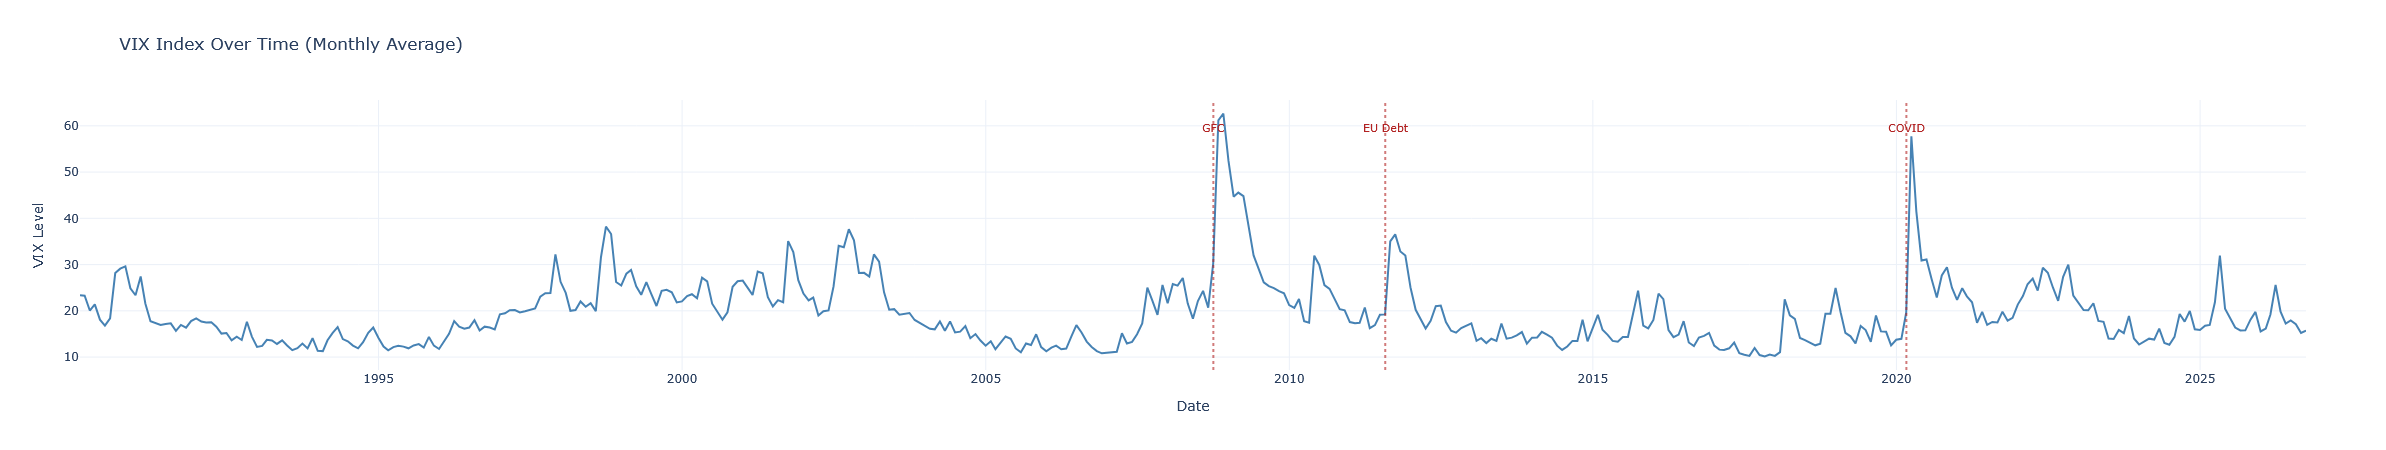

In [11]:
# VIX Index
# Pulled from a public GitHub dataset maintained by the datasets organisation.
# We resample to monthly frequency to reduce noise in the visualisation.

vix_url = "https://raw.githubusercontent.com/datasets/finance-vix/main/data/vix-daily.csv"
vix = pd.read_csv(vix_url)
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix_monthly = vix.resample('ME', on='DATE').mean().reset_index()

fig_vix = go.Figure()

fig_vix.add_trace(go.Scatter(
    x=vix_monthly['DATE'],
    y=vix_monthly['CLOSE'],
    mode='lines',
    name='VIX (monthly avg)',
    line=dict(color='steelblue'),
    hovertemplate='%{x|%b %Y}<br>VIX: %{y:.1f}<extra></extra>'
))

# Annotate key stress periods for context
for event, date, position in [
    ('GFC',        '2008-10-01', 'top left'),
    ('EU Debt',    '2011-08-01', 'top right'),
    ('COVID',      '2020-03-01', 'top left'),
]:
    fig_vix.add_vline(
        x=date, line_dash='dot',
        line_color='firebrick', opacity=0.6
    )
    fig_vix.add_annotation(
        x=date, y=vix_monthly['CLOSE'].max() * 0.95,
        text=event, showarrow=False,
        font=dict(color='firebrick', size=11)
    )

fig_vix.update_layout(
    title='VIX Index Over Time (Monthly Average)',
    xaxis_title='Date',
    yaxis_title='VIX Level',
    hovermode='x unified',
    template='plotly_white',
    height=450
)

fig_vix.show()

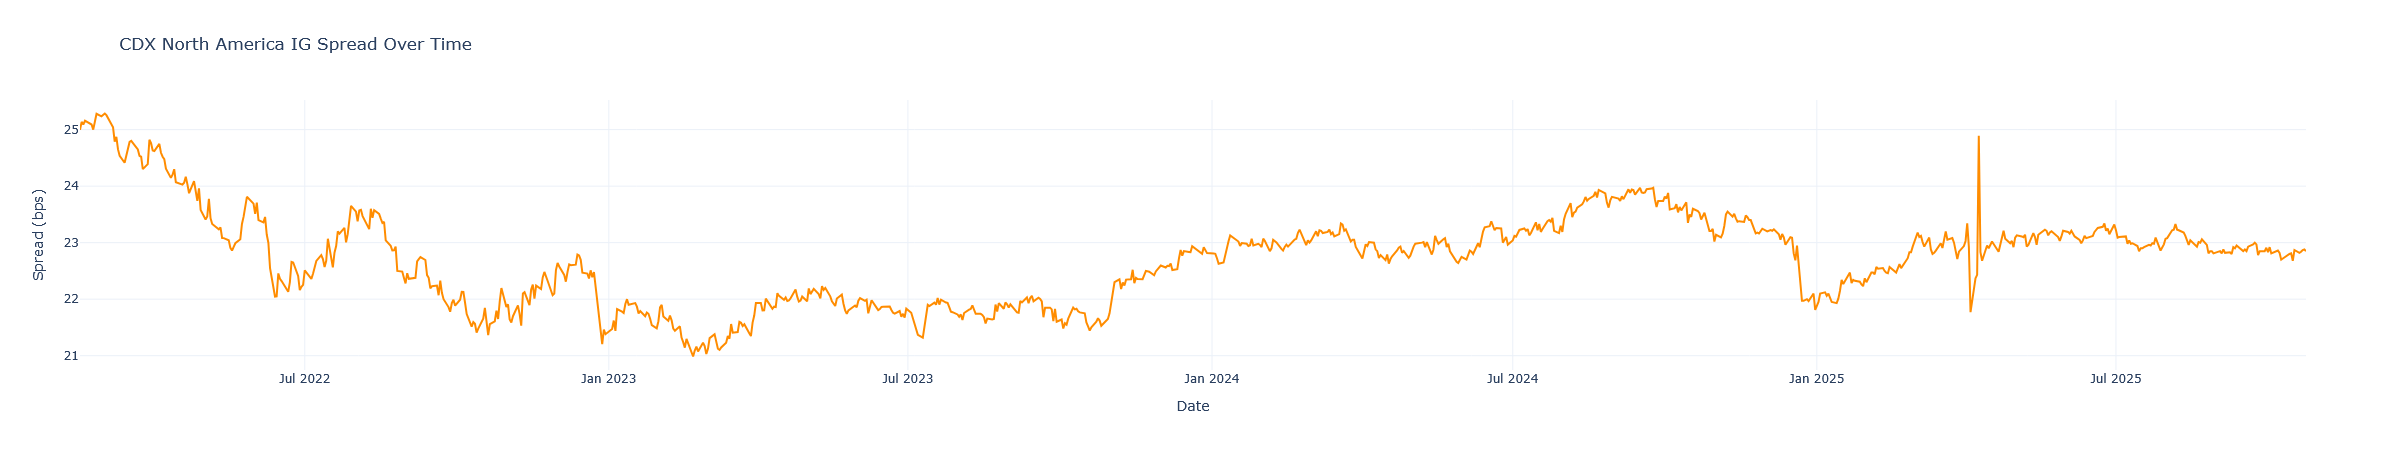

In [12]:
# CDX North America Investment Grade Index
# Read from local CSV. The Close/Last column contains index price levels,
# which we convert to spread in basis points, then to implied hazard rates.

RECOVERY_RATE = 0.40   # Standard assumption for IG CDS contracts

cdx = pd.read_csv("CDX_index_hist.csv")
cdx['Date'] = pd.to_datetime(cdx['Date'], format='%m/%d/%Y')
cdx = cdx.sort_values('Date').reset_index(drop=True)

# CDX is quoted as a price, not directly as a spread.
# Close/Last here represents the spread level in bps.
cdx['Spread_bps']    = cdx['Close/Last']
cdx['HazardRate']    = (cdx['Spread_bps'] / 10_000) / (1 - RECOVERY_RATE)

fig_cdx = go.Figure()

fig_cdx.add_trace(go.Scatter(
    x=cdx['Date'],
    y=cdx['Spread_bps'],
    mode='lines',
    name='CDX IG Spread',
    line=dict(color='darkorange'),
    hovertemplate='%{x|%d %b %Y}<br>Spread: %{y:.1f} bps<extra></extra>'
))

fig_cdx.update_layout(
    title='CDX North America IG Spread Over Time',
    xaxis_title='Date',
    yaxis_title='Spread (bps)',
    hovermode='x unified',
    template='plotly_white',
    height=450
)

fig_cdx.show()

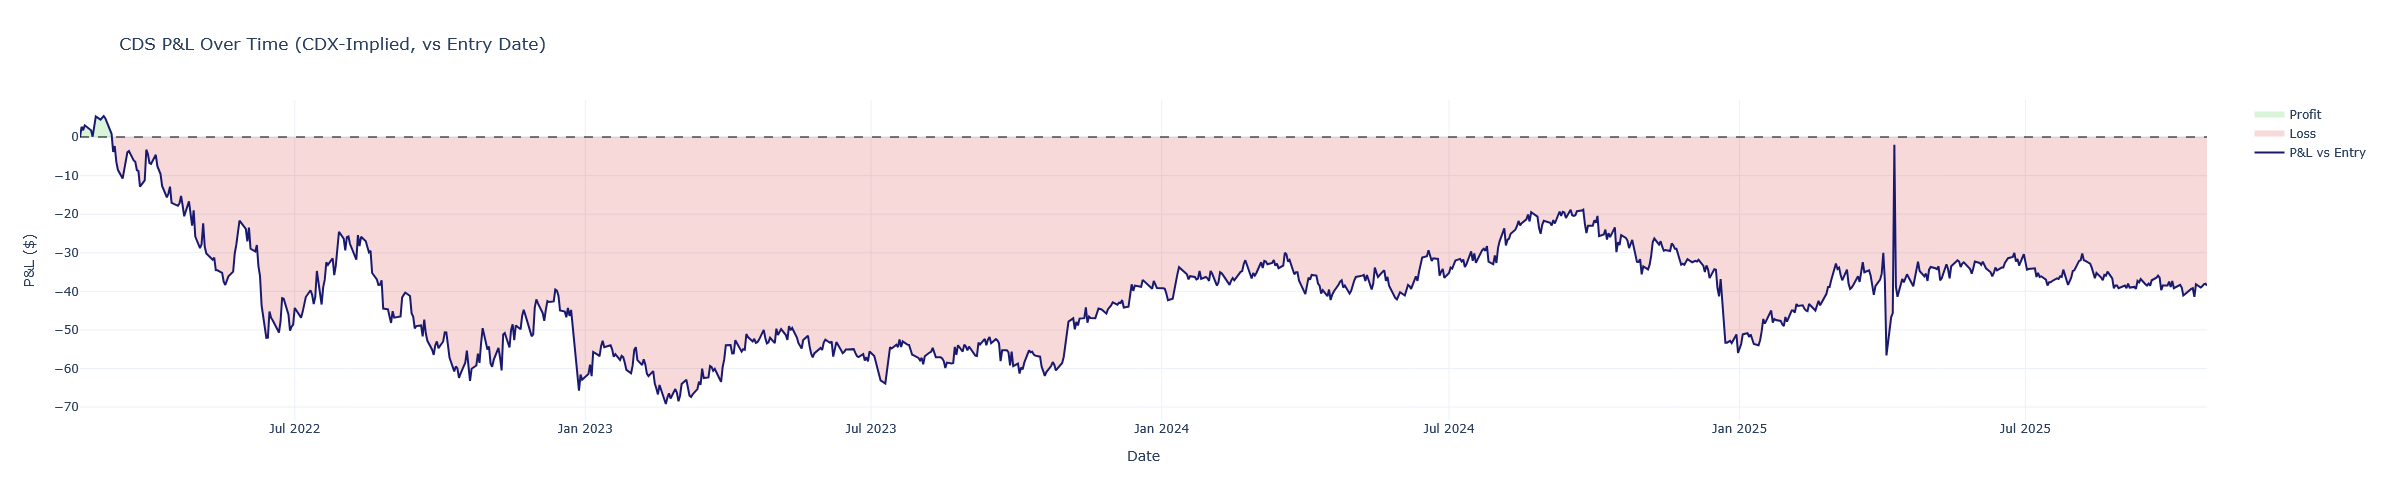

In [13]:
# CDX-Implied CDS NPV Over Time
# Price a hypothetical 5-year $10m CDS at each historical CDX spread level.
# NPV is measured relative to the first observation, treating that date as
# the trade entry point.

NOTIONAL_M    = 10
MATURITY      = 5
DISCOUNT_RATE = 0.03

npvs = []
for _, row in cdx.iterrows():
    _, _, npv = cds_pv(
        notional_m    = NOTIONAL_M,
        spread_bps    = row['Spread_bps'],
        maturity      = MATURITY,
        recovery_rate = RECOVERY_RATE,
        discount_rate = DISCOUNT_RATE,
        hazard_rate   = row['HazardRate']
    )
    npvs.append(npv)

cdx['NPV'] = npvs
entry_npv   = cdx['NPV'].iloc[0]
cdx['PnL']  = cdx['NPV'] - entry_npv

fig_npv = go.Figure()

# Zero reference line
fig_npv.add_hline(
    y=0, line_dash='dash',
    line_color='black', opacity=0.5
)

# P&L fill
fig_npv.add_trace(go.Scatter(
    x=cdx['Date'],
    y=np.where(cdx['PnL'] > 0, cdx['PnL'], 0),
    fill='tozeroy', mode='none',
    fillcolor='rgba(0, 180, 0, 0.15)',
    name='Profit', hoverinfo='skip'
))

fig_npv.add_trace(go.Scatter(
    x=cdx['Date'],
    y=np.where(cdx['PnL'] < 0, cdx['PnL'], 0),
    fill='tozeroy', mode='none',
    fillcolor='rgba(200, 0, 0, 0.15)',
    name='Loss', hoverinfo='skip'
))

# P&L line
fig_npv.add_trace(go.Scatter(
    x=cdx['Date'],
    y=cdx['PnL'],
    mode='lines',
    name='P&L vs Entry',
    line=dict(color='midnightblue'),
    hovertemplate='%{x|%d %b %Y}<br>P&L: $%{y:,.0f}<extra></extra>'
))

fig_npv.update_layout(
    title='CDS P&L Over Time (CDX-Implied, vs Entry Date)',
    xaxis_title='Date',
    yaxis_title='P&L ($)',
    hovermode='x unified',
    template='plotly_white',
    height=500
)

fig_npv.show()

## Stress Testing: Parallel Credit Spread Shifts

The stress testing module measures how the value of a CDS position changes under 
adverse credit conditions. We apply a series of parallel spread shifts to the base 
case and reprice the contract at each shock level using the full pricing model.

**CS01** is the sensitivity of the CDS NPV to a 1 basis point increase in the 
credit spread. It is computed via bump-and-reprice: price the contract at the base 
spread, price it again at base spread + 1bp, take the difference.

**Scenario P&L** extends this across a range of stress scenarios. Because we reprice 
fully at each shock level rather than simply scaling CS01, the results naturally 
capture the convexity of the position: large spread moves produce disproportionately 
larger P&L than small ones.

A positive NPV change means the position has gained value. For a protection buyer, 
spread widening is profitable: the contract they hold becomes more valuable as the 
reference entity becomes more likely to default.

In [18]:
# CS01: Credit Spread Sensitivity
# CS01 is the change in NPV for a 1bp increase in the credit spread.
# Computed via bump-and-reprice: the standard practitioner approach.

# Base case parameters
NOTIONAL_M    = 10
SPREAD_BPS    = 150
MATURITY      = 5
RECOVERY_RATE = 0.40
DISCOUNT_RATE = 0.03

# Implied hazard rate from base spread: lambda ≈ spread / (1 - recovery)
base_hazard   = (SPREAD_BPS / 10_000) / (1 - RECOVERY_RATE)

# Base case price
_, _, npv_base = cds_pv(
    NOTIONAL_M, SPREAD_BPS, MATURITY,
    RECOVERY_RATE, DISCOUNT_RATE, base_hazard
)

# Bumped price: spread + 1bp, hazard rate updated consistently
bump_bps      = 1
bumped_spread = SPREAD_BPS + bump_bps
bumped_hazard = (bumped_spread / 10_000) / (1 - RECOVERY_RATE)

_, _, npv_bumped = cds_pv(
    NOTIONAL_M, bumped_spread, MATURITY,
    RECOVERY_RATE, DISCOUNT_RATE, bumped_hazard
)

cs01 = npv_bumped - npv_base

print("CS01 Calculation")
print(f"Base Spread:       {SPREAD_BPS:.0f} bps")
print(f"Base Hazard Rate:  {base_hazard*100:.4f}%")
print(f"Base NPV:          ${npv_base:>12,.2f}")
print(f"Bumped NPV:        ${npv_bumped:>12,.2f}")
print(f"CS01:              ${cs01:>12,.2f} per bp")
print()
print(f"Interpretation: a 1bp widening in the credit spread changes")
print(f"the position value by ${cs01:,.2f}.")
print(f"Linear approximation for 100bp move: ${cs01 * 100:,.2f}")

CS01 Calculation
Base Spread:       150 bps
Base Hazard Rate:  2.5000%
Base NPV:          $    8,039.93
Bumped NPV:        $    8,144.02
CS01:              $      104.09 per bp

Interpretation: a 1bp widening in the credit spread changes
the position value by $104.09.
Linear approximation for 100bp move: $10,408.73


In [19]:
# Parallel Spread Shift Scenarios
# We apply a range of spread shocks and reprice fully at each level.
# P&L is measured as the change in NPV relative to the base case.
# The difference between actual P&L and the CS01-scaled approximation
# reveals the convexity effect: larger moves are disproportionately profitable
# for the protection buyer because the protection leg is convex in spread.

scenarios_bps = [1, 10, 25, 50, 100, 200, 300, 500]
results = []

for shock in scenarios_bps:
    stressed_spread = SPREAD_BPS + shock
    stressed_hazard = (stressed_spread / 10_000) / (1 - RECOVERY_RATE)

    _, _, npv_stressed = cds_pv(
        NOTIONAL_M, stressed_spread, MATURITY,
        RECOVERY_RATE, DISCOUNT_RATE, stressed_hazard
    )

    pnl_actual      = npv_stressed - npv_base
    pnl_linear      = cs01 * shock          # Simple CS01 scaling
    convexity_effect = pnl_actual - pnl_linear

    results.append({
        'Shock (bps)'        : shock,
        'Stressed Spread'    : stressed_spread,
        'NPV ($)'            : round(npv_stressed, 2),
        'P&L ($)'            : round(pnl_actual, 2),
        'CS01 Approx ($)'    : round(pnl_linear, 2),
        'Convexity Effect ($)': round(convexity_effect, 2)
    })

df_stress = pd.DataFrame(results)

# Format for display
df_display = df_stress.copy()
for col in ['NPV ($)', 'P&L ($)', 'CS01 Approx ($)', 'Convexity Effect ($)']:
    df_display[col] = df_display[col].apply(lambda x: f"${x:>12,.0f}")

print("Parallel Spread Shift Stress Test")
print(f"Base Case: {SPREAD_BPS}bps spread, ${NOTIONAL_M}m notional, "
      f"{MATURITY}yr maturity, {RECOVERY_RATE*100:.0f}% recovery\n")
print(df_display.to_string(index=False))

Parallel Spread Shift Stress Test
Base Case: 150bps spread, $10m notional, 5yr maturity, 40% recovery

 Shock (bps)  Stressed Spread       NPV ($)       P&L ($) CS01 Approx ($) Convexity Effect ($)
           1              151 $       8,144 $         104   $         104        $           0
          10              160 $       9,109 $       1,069   $       1,041        $          28
          25              175 $      10,828 $       2,788   $       2,602        $         185
          50              200 $      13,993 $       5,953   $       5,204        $         749
         100              250 $      21,408 $      13,368   $      10,409        $       2,959
         200              350 $      40,244 $      32,204   $      20,817        $      11,387
         300              450 $      63,843 $      55,803   $      31,226        $      24,577
         500              650 $     122,881 $     114,841   $      52,044        $      62,797


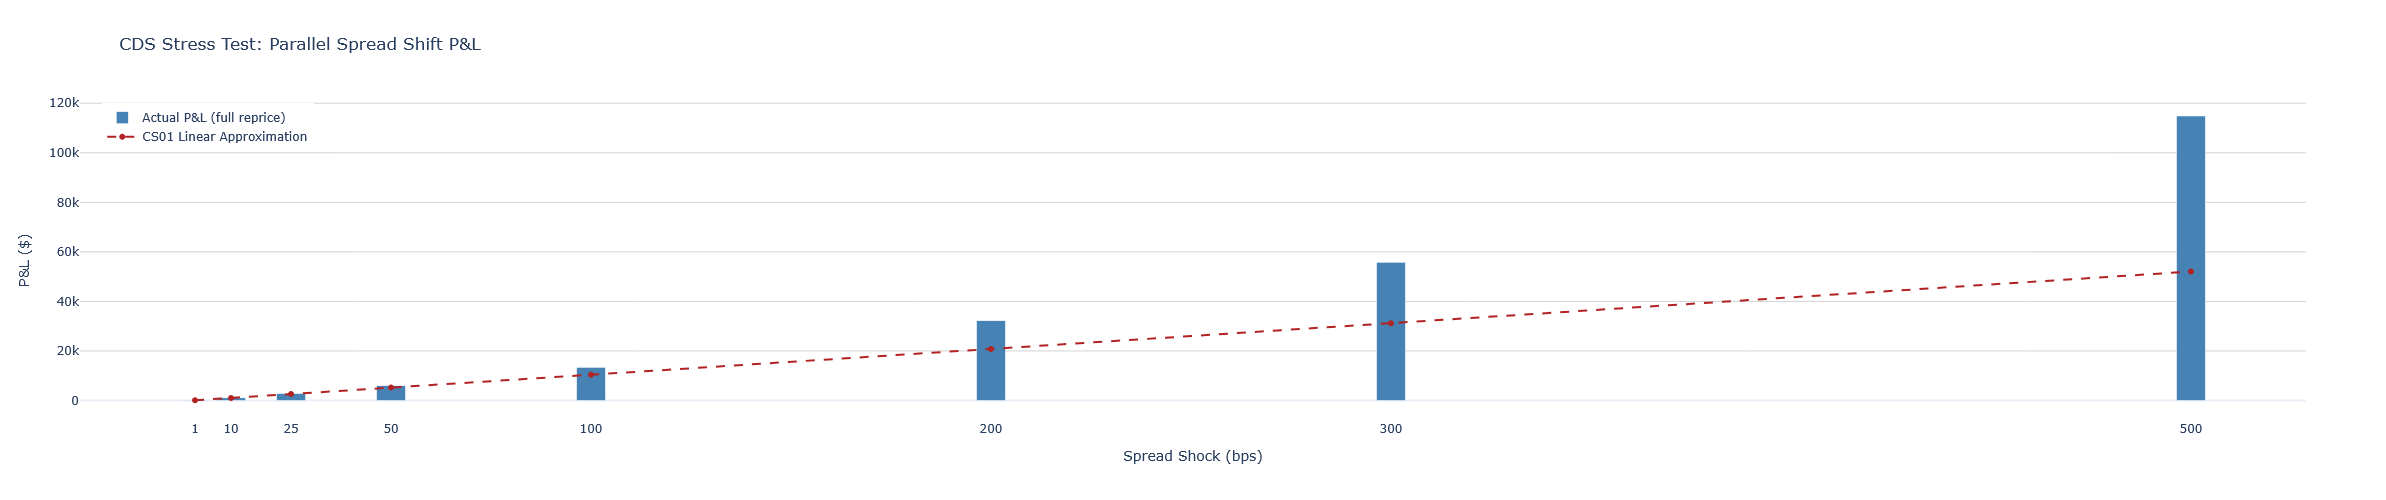

In [17]:
# Stress Test Visualisation

shocks = df_stress['Shock (bps)']
pnl    = df_stress['P&L ($)']
approx = df_stress['CS01 Approx ($)']

fig_stress = go.Figure()

# Actual P&L bars
fig_stress.add_trace(go.Bar(
    x=shocks, y=pnl,
    name='Actual P&L (full reprice)',
    marker_color='steelblue',
    hovertemplate='Shock: +%{x}bps<br>Actual P&L: $%{y:,.0f}<extra></extra>'
))

# CS01 linear approximation line
fig_stress.add_trace(go.Scatter(
    x=shocks, y=approx,
    mode='lines+markers',
    name='CS01 Linear Approximation',
    line=dict(color='firebrick', dash='dash'),
    hovertemplate='Shock: +%{x}bps<br>CS01 Approx: $%{y:,.0f}<extra></extra>'
))

fig_stress.update_layout(
    title='CDS Stress Test: Parallel Spread Shift P&L',
    xaxis=dict(
        title='Spread Shock (bps)',
        tickvals=scenarios_bps
    ),
    yaxis=dict(
        title='P&L ($)',
        showgrid=True,
        gridcolor='LightGray'
    ),
    hovermode='x unified',
    template='plotly_white',
    height=500,
    legend=dict(x=0.01, y=0.99)
)

fig_stress.show()